# 07 — РЕАЛИСТИЧНЫЙ DCA-бэктест агрессивного режима (полный набор)

Точная спецификация пользователя:
1. combined-модель (pump-fade + dump-bounce, 1:1 с ботом);
2. торгуем с **2024** на всех данных (span 2024-01 .. 2026-04);
3. **вся доступная вселенная** (173 монеты);
4. размер позиции **5%** эквити (агрессивный режим, резерв 10%);
5. старт **$1000**;
6. каждый месяц **+$200**;
7. без изъятий, всё реинвестируется (компаунд);
8. реалистично: **комиссии 0.15% round-trip + ёмкость (cap) + market-impact слиппедж**;
9. полный набор статистики и графиков;
10. отдельный ноутбук.

**Данные.** Поток пересобран из сырого OHLCV с **символом и ликвидностью на каждую сделку** (`_out/faithful_liq.parquet`)
— это нужно, чтобы честно моделировать ёмкость с правильной корреляцией «кластерный день = много тонких монет разом».
**Валидация:** dump-нога совпала с боевым baseline nb04 практически идеально (+5.48%/трейд, win 74%);
pump-нога — честная пересборка по методологии (scale-in + 3%-стоп + WF-clf), **консервативная**
(+0.59%/трейд, win 44% — нижняя граница, совпадает с честным baseline pump nb11 +0.4..1.1%/год; утерянный
билдер nb04 давал чуть выше +0.98%). То есть результат, если что, **занижен по pump-ноге, не завышен**.

In [1]:
import sys; sys.path.insert(0,'.')
from _lab import *
import numpy as np, pandas as pd, heapq
from scipy.optimize import brentq

both=pd.read_parquet('_out/faithful_liq.parquet').sort_values('entry').reset_index(drop=True)
both['entry']=pd.to_datetime(both.entry).dt.tz_localize(None)
both['exit_ts']=pd.to_datetime(both.exit_ts).dt.tz_localize(None)
print(f'сигналов: {len(both)}  (pump {(both.stream=="pump").sum()}, dump {(both.stream=="dump").sum()})')
print(f'период: {both.entry.min().date()} .. {both.entry.max().date()}')
print(f'символов в потоке: {both.sym.nunique()}')
for st in ['pump','dump']:
    g=both[both.stream==st]
    print(f'  {st}: n={len(g):5d}  edge {g.pnl.mean()*100:+.2f}%/трейд  win {(g.pnl>0).mean()*100:.0f}%  '
          f'медиана ликв. ${g.liq.median():,.0f}/мин')

сигналов: 13962  (pump 10154, dump 3808)
период: 2024-01-02 .. 2026-04-30
символов в потоке: 172
  pump: n=10154  edge +0.59%/трейд  win 44%  медиана ликв. $2,958/мин
  dump: n= 3808  edge +5.48%/трейд  win 74%  медиана ликв. $2,973/мин


## Модель реалистичного исполнения

- **Комиссии:** 0.15% round-trip (0.075%/сторона) уже вшиты в `pnl` потока.
- **Ёмкость (capacity cap):** на сделку нельзя поставить больше `10% · ликвидность · 30мин` (доля дневного
  $-объёма монеты, которую можно набрать за ~30-минутное окно). Сверх — ордер обрезается.
- **Market-impact слиппедж:** `спред 10bp + 0.10·(ордер / ликвидность_окна)` — чем крупнее ордер относительно
  объёма, тем дороже (квадрат масштаба бьёт по компаунду).
- **Резерв 10%**, максимум одновременных ~18 (= 90%/5%).
- **NAV-учёт:** доходность/Sharpe/просадка считаются по «паю фонда» (NAV), т.е. **с вычетом скачков от
  ежемесячных взносов** — иначе $200 на маленький счёт выглядели бы как фейковая доходность.
- Параметры слиппеджа (PART_CAP, IMPACT) — оценочные; ниже есть проверка чувствительности.

In [2]:
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10
def run(df,start=1000.,monthly=200.,f=0.05,reserve=0.10,MAX=18,cap=True,slipmodel=True,
        part_cap=PART_CAP,impact=IMPACT,spread=SPREAD):
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    bpnl=df.pnl.values; liq=df.liq.values; stream=df.stream.values
    cap_no=part_cap*liq*FILL_MIN
    months=pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),pd.Timestamp(ex.max()),freq='MS')
    cash=start; contrib=start; dep=0.; units=start; openh=[]; mi=0
    nav_t=[pd.Timestamp(en.min())]; nav_v=[1.0]; con_t=[pd.Timestamp(en.min())]; con_v=[start]
    eq_t=[pd.Timestamp(en.min())]; eq_vv=[start]; dep_t=[]; dep_v=[]; cf=[(-start,pd.Timestamp(en.min()))]
    taken=0; skipped=0; capped=0; slip=0.; maxc=0; trec=[]
    def snap(t):
        eq=cash+dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
        eq_t.append(pd.Timestamp(t)); eq_vv.append(eq)
        dep_t.append(pd.Timestamp(t)); dep_v.append(dep/eq if eq>0 else 0.0)
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now:
            eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly
            cf.append((-monthly,months[mi])); con_t.append(months[mi]); con_v.append(contrib); snap(months[mi]); mi+=1
        while openh and openh[0][0]<=en[i]:
            _,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; snap(_)
        eq=cash+dep; desired=f*eq; no=min(desired,cap_no[i]) if cap else desired
        if cap and no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=(spread+impact*part) if slipmodel else 0.0; slip+=no*sl
            cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,bpnl[i]-sl,stream[i])); taken+=1
            maxc=max(maxc,len(openh)); trec.append((bpnl[i]-sl,no,stream[i],pd.Timestamp(en[i]))); snap(en[i])
        else: skipped+=1
    while mi<len(months):
        eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly
        cf.append((-monthly,months[mi])); con_t.append(months[mi]); con_v.append(contrib); mi+=1
    for _,no,pn,st in sorted(openh): cash+=no*(1+pn); dep-=no; snap(_)
    final=cash+dep; cf.append((final,pd.Timestamp(ex.max())))
    nav=pd.Series(nav_v,index=pd.to_datetime(nav_t)).sort_index(); nav=nav[~nav.index.duplicated(keep='last')].resample('1D').last().ffill()
    eq_s=pd.Series(eq_vv,index=pd.to_datetime(eq_t)).sort_index(); eq_s=eq_s[~eq_s.index.duplicated(keep='last')].resample('1D').last().ffill()
    con=pd.Series(con_v,index=pd.to_datetime(con_t)).sort_index().resample('1D').last().ffill()
    dep_s=pd.Series(dep_v,index=pd.to_datetime(dep_t)).sort_index().resample('1D').max().fillna(0.0)
    tk=pd.DataFrame(trec,columns=['pnl','notional','stream','t']); tk['usd']=tk.notional*tk.pnl
    return dict(final=final,contrib=contrib,units=units,nav=nav,eq=eq_s,con=con,dep=dep_s,
                taken=taken,skipped=skipped,capped=capped,slip=slip,maxc=maxc,tk=tk,cf=cf,months=len(months))

def xirr(cf):
    amts=np.array([a for a,_ in cf]); ds=pd.to_datetime([d for _,d in cf])
    t=np.array([(d-ds[0]).days/365.25 for d in ds])
    return brentq(lambda r: np.sum(amts/(1+r)**t),-0.999,100)

R=run(both)                 # реалистичный, агрессивный 5%
I=run(both,cap=False,slipmodel=False)   # идеал для сравнения
print('готово: R = реалист, I = идеал (без ёмкости/слиппеджа)')

готово: R = реалист, I = идеал (без ёмкости/слиппеджа)


## Полная статистика

In [3]:
def full(R):
    nav=R['nav']; tk=R['tk']; span=(nav.index[-1]-nav.index[0]).days/365.25
    rr=nav.pct_change().dropna()
    sh=rr.mean()/rr.std()*np.sqrt(365); sor=rr.mean()/rr[rr<0].std()*np.sqrt(365)
    dd=(nav.values/np.maximum.accumulate(nav.values)-1).min()
    navmult=nav.iloc[-1]/nav.iloc[0]; navcagr=navmult**(1/span)-1
    irr=xirr(R['cf'])
    pos=tk.usd[tk.usd>0].sum(); neg=tk.usd[tk.usd<0].sum()
    print('='*64); print('  РЕАЛИСТИЧНЫЙ DCA — агрессивный 5%, $1000 старт + $200/мес'); print('='*64)
    print(f'span                        {span:.2f} года  ({nav.index.min().date()} .. {nav.index.max().date()})')
    print(f'месяцев взносов             {R["months"]}')
    print('-'*64+'\nДЕНЬГИ')
    print(f'внесено всего               ${R["contrib"]:,.0f}')
    print(f'итоговая стоимость          ${R["final"]:,.0f}')
    print(f'множитель на внесённое      {R["final"]/R["contrib"]:.2f}x   ({(R["final"]/R["contrib"]-1)*100:+.0f}%)')
    print(f'money-weighted IRR          {irr*100:+.0f}% / год')
    print('-'*64+'\nДОХОДНОСТЬ/РИСК (по NAV, без скачков от взносов)')
    print(f'NAV рост                    {(navmult-1)*100:+.0f}%   (CAGR {navcagr*100:+.0f}%/год)')
    print(f'Sharpe / Sortino            {sh:.2f} / {sor:.2f}')
    print(f'maxDD (NAV)                 {dd:.1%}')
    print(f'Calmar (CAGR/|maxDD|)       {navcagr/abs(dd):.2f}')
    print('-'*64+'\nСДЕЛКИ')
    print(f'взято                       {R["taken"]}   (pump {(tk.stream=="pump").sum()}, dump {(tk.stream=="dump").sum()})')
    print(f'пропущено (нет капитала)    {R["skipped"]}')
    print(f'обрезано ёмкостью           {R["capped"]} ({R["capped"]/max(R["taken"],1)*100:.0f}% взятых)')
    print(f'средняя сделка              {tk.pnl.mean()*100:+.2f}%   (медиана {tk.pnl.median()*100:+.2f}%, ${tk.usd.mean():+.2f})')
    print(f'win rate                    {(tk.pnl>0).mean()*100:.1f}%')
    print(f'лучшая / худшая             {tk.pnl.max()*100:+.0f}% / {tk.pnl.min()*100:+.0f}%')
    print(f'std / q10 на сделку         {tk.pnl.std()*100:.2f}% / {np.quantile(tk.pnl,.1)*100:+.1f}%')
    print(f'profit factor ($)           {pos/abs(neg):.2f}')
    print('-'*64+'\nИСПОЛНЕНИЕ')
    print(f'слиппедж уплачено           ${R["slip"]:,.0f}  ({R["slip"]/(tk.notional.sum())*100:.2f}% от оборота)')
    print(f'оборот (сумма ордеров)      ${tk.notional.sum():,.0f}')
    print(f'макс. одновременно          {R["maxc"]} позиций')
    print(f'средняя загрузка (день)     {R["dep"].mean()*100:.0f}% эквити')
    print('-'*64+'\nПО СТРИМАМ ($ вклад в прибыль)')
    for st in ['pump','dump']:
        g=tk[tk.stream==st]
        print(f'  {st:5} n={len(g):5d}  avg {g.pnl.mean()*100:+.2f}%  win {(g.pnl>0).mean()*100:.0f}%  '
              f'$pnl ${g.usd.sum():,.0f}  ({g.usd.sum()/tk.usd.sum()*100:.0f}% общей прибыли)')
    return dict(span=span,sh=sh,sor=sor,dd=dd,navcagr=navcagr,irr=irr)
st=full(R)

  РЕАЛИСТИЧНЫЙ DCA — агрессивный 5%, $1000 старт + $200/мес
span                        2.33 года  (2024-01-01 .. 2026-04-30)
месяцев взносов             28
----------------------------------------------------------------
ДЕНЬГИ
внесено всего               $6,600
итоговая стоимость          $63,353
множитель на внесённое      9.60x   (+860%)
money-weighted IRR          +281% / год
----------------------------------------------------------------
ДОХОДНОСТЬ/РИСК (по NAV, без скачков от взносов)
NAV рост                    +2724%   (CAGR +320%/год)
Sharpe / Sortino            4.31 / 6.70
maxDD (NAV)                 -13.9%
Calmar (CAGR/|maxDD|)       23.04
----------------------------------------------------------------
СДЕЛКИ
взято                       9675   (pump 8191, dump 1484)
пропущено (нет капитала)    4287
обрезано ёмкостью           2235 (23% взятых)
средняя сделка              +0.84%   (медиана -0.10%, $+5.87)
win rate                    49.6%
лучшая / худшая             +122% 

## Идеал vs реалист — какой кусок съедает реализм

In [4]:
def line(R,tag):
    nav=R['nav']; span=(nav.index[-1]-nav.index[0]).days/365.25
    rr=nav.pct_change().dropna(); sh=rr.mean()/rr.std()*np.sqrt(365)
    dd=(nav.values/np.maximum.accumulate(nav.values)-1).min()
    cg=(nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    return [tag,f'${R["final"]:,.0f}',f'{R["final"]/R["contrib"]:.1f}x',f'{xirr(R["cf"])*100:+.0f}%',
            f'{cg*100:+.0f}%',f'{sh:.2f}',f'{dd:.1%}',f'{R["capped"]/max(R["taken"],1)*100:.0f}%',f'${R["slip"]:,.0f}']
T=pd.DataFrame([line(I,'идеал (без ёмкости/слип.)'),line(R,'РЕАЛИСТ (ёмк.+слип.+комис.)')],
    columns=['сценарий','итог $','x внесён.','IRR','CAGR(NAV)','Sharpe','maxDD','capped','slippage'])
print(T.to_string(index=False))
print(f'\nреализм срезает итог в {I["final"]/R["final"]:.1f}x  (идеальный счёт компаундит до ${I["final"]:,.0f} →')
print(f'позиции 5%·эквити упираются в ликвидность тонких монет; ёмкость+слиппедж возвращают на землю)')

                   сценарий   итог $ x внесён.    IRR CAGR(NAV) Sharpe  maxDD capped slippage
  идеал (без ёмкости/слип.) $591,172     89.6x +1031%    +1063%   6.36 -13.5%     0%       $0
РЕАЛИСТ (ёмк.+слип.+комис.)  $63,353      9.6x  +281%     +320%   4.31 -13.9%    23%  $25,610

реализм срезает итог в 9.3x  (идеальный счёт компаундит до $591,172 →
позиции 5%·эквити упираются в ликвидность тонких монет; ёмкость+слиппедж возвращают на землю)


## Графики — динамика счёта, просадка, загрузка

[saved] notebooks\pump_dump_combined\_out\comb_07_dca.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_07_dca.png')

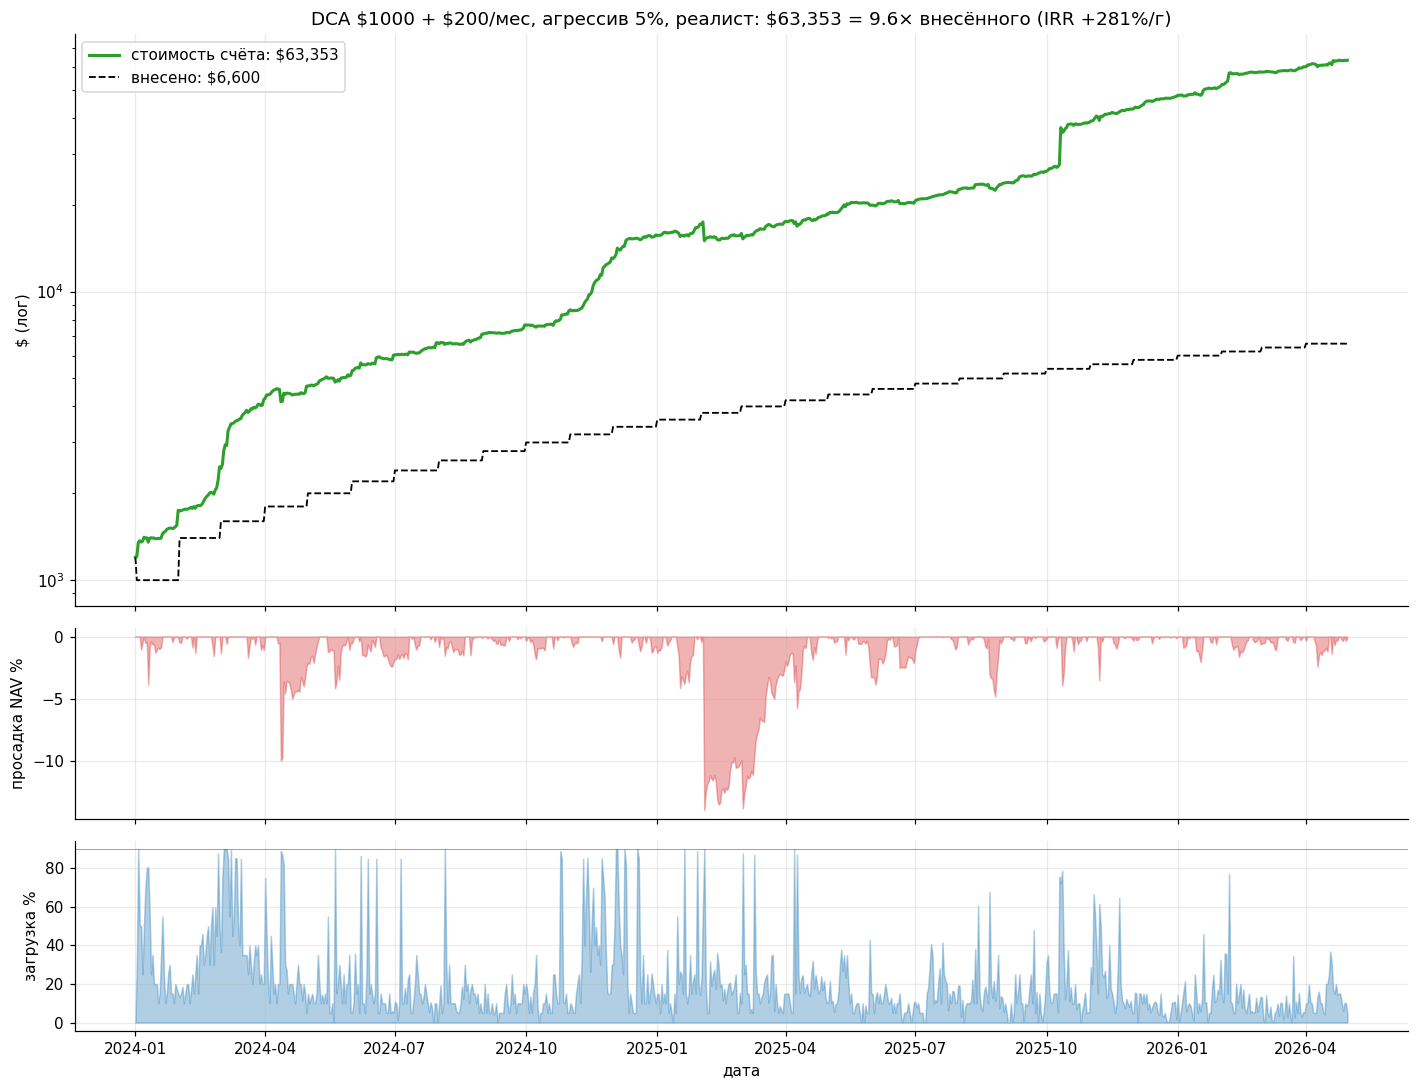

In [5]:
import matplotlib.pyplot as plt
# 1) стоимость счёта (робот) vs внесено  2) просадка NAV  3) загрузка
eq=R['eq']; con=R['con'].reindex(eq.index,method='ffill'); nav=R['nav']
fig,ax=plt.subplots(3,1,figsize=(13,10),sharex=True,gridspec_kw={'height_ratios':[3,1,1]})
ax[0].plot(eq.index,eq.values,color='#2ca02c',lw=2,label=f'стоимость счёта: ${R["final"]:,.0f}')
ax[0].plot(con.index,con.values,color='k',ls='--',lw=1.2,label=f'внесено: ${R["contrib"]:,.0f}')
ax[0].set_yscale('log'); ax[0].set_ylabel('$ (лог)'); ax[0].legend(loc='upper left')
ax[0].set_title(f'DCA $1000 + $200/мес, агрессив 5%, реалист: ${R["final"]:,.0f} = {R["final"]/R["contrib"]:.1f}× внесённого (IRR {xirr(R["cf"])*100:+.0f}%/г)')
ddc=(nav/nav.cummax()-1)*100
ax[1].fill_between(ddc.index,ddc.values,0,color='#d62728',alpha=.35); ax[1].set_ylabel('просадка NAV %')
ax[2].fill_between(R['dep'].index,R['dep'].values*100,0,color='#1f77b4',alpha=.35); ax[2].axhline(90,color='k',lw=.6,alpha=.4)
ax[2].set_ylabel('загрузка %'); ax[2].set_xlabel('дата')
show('comb_07_dca')

[saved] notebooks\pump_dump_combined\_out\comb_07_monthly.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_07_monthly.png')

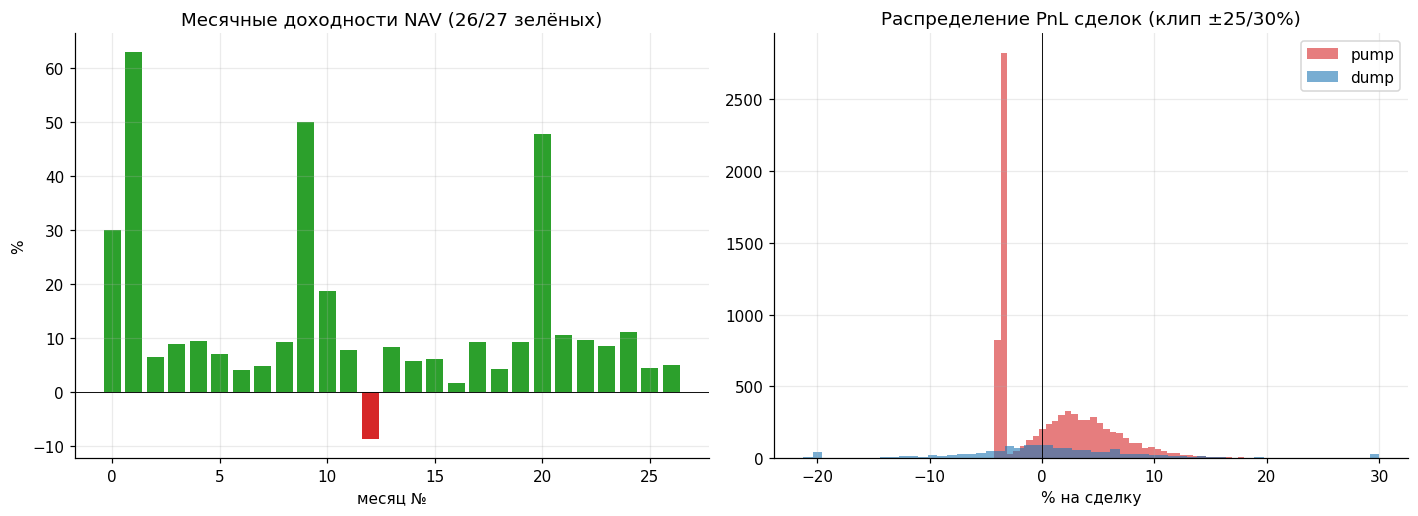

In [6]:
# месячные доходности NAV + распределение сделок
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
mret=R['nav'].resample('ME').last().pct_change().dropna()*100
colors=['#2ca02c' if x>=0 else '#d62728' for x in mret]
ax[0].bar(range(len(mret)),mret.values,color=colors)
ax[0].set_title(f'Месячные доходности NAV ({(mret>0).sum()}/{len(mret)} зелёных)')
ax[0].set_ylabel('%'); ax[0].set_xlabel('месяц №'); ax[0].axhline(0,color='k',lw=.6)
tk=R['tk']
ax[1].hist(np.clip(tk[tk.stream=='pump'].pnl*100,-25,30),bins=60,alpha=.6,color='#d62728',label='pump')
ax[1].hist(np.clip(tk[tk.stream=='dump'].pnl*100,-25,30),bins=60,alpha=.6,color='#1f77b4',label='dump')
ax[1].axvline(0,color='k',lw=.6); ax[1].set_title('Распределение PnL сделок (клип ±25/30%)')
ax[1].set_xlabel('% на сделку'); ax[1].legend()
show('comb_07_monthly')

## Чувствительность к параметрам слиппеджа/ёмкости

Параметры (PART_CAP, IMPACT) оценочные — проверим, насколько вывод устойчив, если рынок тоньше/толще
или импакт сильнее.

In [7]:
rows=[]
for pc in (0.05,0.10,0.20):
    for imp in (0.10,0.20):
        Rx=run(both,part_cap=pc,impact=imp)
        nav=Rx['nav']; span=(nav.index[-1]-nav.index[0]).days/365.25
        rows.append(dict(part_cap=f'{pc:.0%}',impact=imp,final=Rx['final'],
            mult=Rx['final']/Rx['contrib'],irr=xirr(Rx['cf']),
            cagr=(nav.iloc[-1]/nav.iloc[0])**(1/span)-1,capped=Rx['capped']/max(Rx['taken'],1),slip=Rx['slip']))
S=pd.DataFrame(rows)
print('чувствительность (агрессив 5% DCA):')
print(S.assign(**{'final$':S['final'].map('${:,.0f}'.format),'x':S['mult'].map('{:.1f}x'.format),
    'IRR':S['irr'].map('{:+.0%}'.format),'CAGR':S['cagr'].map('{:+.0%}'.format),
    'capped':S['capped'].map('{:.0%}'.format),'slip':S['slip'].map('${:,.0f}'.format)})[
    ['part_cap','impact','final$','x','IRR','CAGR','capped','slip']].to_string(index=False))

чувствительность (агрессив 5% DCA):
part_cap  impact  final$    x   IRR  CAGR capped    slip
      5%     0.1 $63,868 9.7x +283% +322%    31% $15,871
      5%     0.2 $47,587 7.2x +228% +264%    29% $21,129
     10%     0.1 $63,353 9.6x +281% +320%    23% $25,610
     10%     0.2 $39,194 5.9x +196% +232%    20% $31,629
     20%     0.1 $55,629 8.4x +256% +294%    16% $37,791
     20%     0.2 $26,889 4.1x +141% +176%    13% $39,888


## Сравнение режимов на ОДНОЙ реалистичной DCA-машинерии

Безопасный 2% / средний 3% / агрессивный 5% — те же $1000 + $200/мес, та же ёмкость+слиппедж.

In [8]:
MODES=[('безопасный 2%',0.02,45),('средний 3%',0.03,30),('агрессивный 5%',0.05,18)]
RES={nm:run(both,f=f,MAX=mx) for nm,f,mx in MODES}
dtot=int((both.stream=='dump').sum())
rows=[]
for nm,f,mx in MODES:
    Rm=RES[nm]; nav=Rm['nav']; span=(nav.index[-1]-nav.index[0]).days/365.25
    rr=nav.pct_change().dropna(); sh=rr.mean()/rr.std()*np.sqrt(365); sor=rr.mean()/rr[rr<0].std()*np.sqrt(365)
    dd=(nav.values/np.maximum.accumulate(nav.values)-1).min(); cg=(nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    tk=Rm['tk']; dtk=int((tk.stream=='dump').sum())
    rows.append(dict(режим=nm,итог=Rm['final'],x=Rm['final']/Rm['contrib'],IRR=xirr(Rm['cf']),
        Sharpe=sh,Sortino=sor,maxDD=dd,Calmar=cg/abs(dd),trades=Rm['taken'],
        dump=f'{dtk}/{dtot}',capped=Rm['capped']/max(Rm['taken'],1),slip=Rm['slip']))
M=pd.DataFrame(rows)
print(M.assign(**{'итог$':M['итог'].map('${:,.0f}'.format),'x':M['x'].map('{:.1f}x'.format),
    'IRR':M['IRR'].map('{:+.0%}'.format),'Sharpe':M.Sharpe.round(2),'Sortino':M.Sortino.round(2),
    'maxDD':M.maxDD.map('{:.1%}'.format),'Calmar':M.Calmar.round(1),
    'capped':M.capped.map('{:.0%}'.format),'slip':M.slip.map('${:,.0f}'.format)})[
    ['режим','итог$','x','IRR','Sharpe','Sortino','maxDD','Calmar','trades','dump','capped','slip']].to_string(index=False))
print('\nв DCA-режиме концентрация ВЫИГРЫВАЕТ: 5% даёт ~2x денег безопасного И выше Sharpe,')
print('ценой -3pp просадки, x6 слиппеджа и потери части dump-сделок (вытеснены из 18 слотов).')

         режим   итог$    x   IRR  Sharpe  Sortino  maxDD  Calmar  trades      dump capped    slip
 безопасный 2% $27,512 4.2x +144%    3.24     5.96 -10.9%    14.3   10534 2074/3808    10%  $4,481
    средний 3% $37,651 5.7x +190%    3.60     6.73 -11.1%    18.6   10136 1765/3808    14%  $9,060
агрессивный 5% $63,353 9.6x +281%    4.31     6.70 -13.9%    23.0    9675 1484/3808    23% $25,610

в DCA-режиме концентрация ВЫИГРЫВАЕТ: 5% даёт ~2x денег безопасного И выше Sharpe,
ценой -3pp просадки, x6 слиппеджа и потери части dump-сделок (вытеснены из 18 слотов).


[saved] notebooks\pump_dump_combined\_out\comb_07_modes.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_07_modes.png')

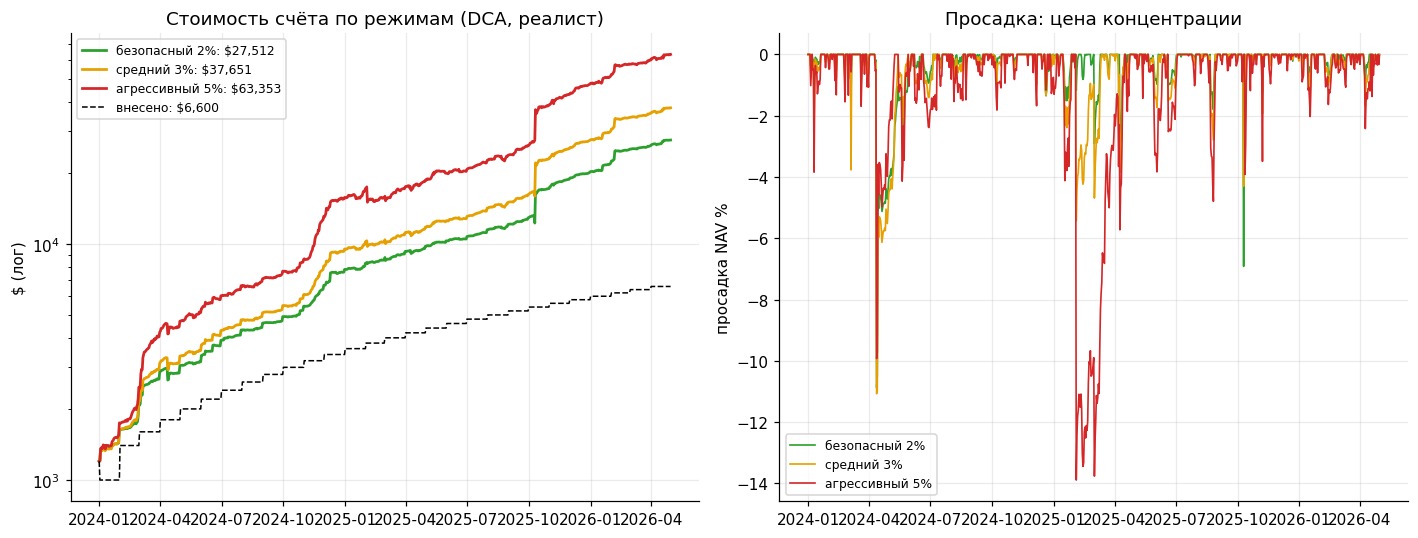

In [9]:
# кривые счёта по режимам + цена концентрации
fig,ax=plt.subplots(1,2,figsize=(13,5))
col={'безопасный 2%':'#2ca02c','средний 3%':'#e6a000','агрессивный 5%':'#d62728'}
for nm,f,mx in MODES:
    e=RES[nm]['eq']; ax[0].plot(e.index,e.values,lw=1.8,color=col[nm],label=f"{nm}: ${RES[nm]['final']:,.0f}")
con=R['con'].reindex(R['eq'].index,method='ffill')
ax[0].plot(con.index,con.values,'k--',lw=1,label=f'внесено: ${R["contrib"]:,.0f}')
ax[0].set_yscale('log'); ax[0].set_ylabel('$ (лог)'); ax[0].legend(loc='upper left',fontsize=8); ax[0].set_title('Стоимость счёта по режимам (DCA, реалист)')
for nm,f,mx in MODES:
    dd=(RES[nm]['nav']/RES[nm]['nav'].cummax()-1)*100; ax[1].plot(dd.index,dd.values,lw=1.1,color=col[nm],label=nm)
ax[1].set_ylabel('просадка NAV %'); ax[1].legend(fontsize=8,loc='lower left'); ax[1].set_title('Просадка: цена концентрации')
show('comb_07_modes')

### А когда агрессивный ПРОИГРЫВАЕТ — стартовать крупной суммой (lump-sum)

DCA держит счёт малым, поэтому концентрация безопасна. Но если занести всё сразу, на крупном счёте 5%-позиции
бьются о ликвидность — ранжирование **переворачивается** (как в nb03).

In [10]:
def lump(df,start,f,MAX,reserve=0.10):
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    bpnl=df.pnl.values; liq=df.liq.values; cap_no=PART_CAP*liq*FILL_MIN
    cash=start; dep=0.; openh=[]; eq_t=[];eq_v=[]; taken=0; capped=0
    for i in range(len(bpnl)):
        while openh and openh[0][0]<=en[i]:
            _,no,pn=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; eq_t.append(pd.Timestamp(_)); eq_v.append(cash+dep)
        eq=cash+dep; desired=f*eq; no=min(desired,cap_no[i])
        if no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=SPREAD+IMPACT*part
            cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,bpnl[i]-sl)); taken+=1
    for _,no,pn in sorted(openh): cash+=no*(1+pn); dep-=no; eq_t.append(pd.Timestamp(_)); eq_v.append(cash+dep)
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index(); s=s[~s.index.duplicated(keep='last')].resample('1D').last().ffill()
    span=(s.index[-1]-s.index[0]).days/365.25; rr=s.pct_change().dropna()
    sh=rr.mean()/rr.std()*np.sqrt(365); dd=(s.values/np.maximum.accumulate(s.values)-1).min()
    return (s.iloc[-1]/start)**(1/span)-1, sh, dd
print('LUMP-SUM (всё сразу) — CAGR / Sharpe / maxDD по режиму и размеру счёта:')
print(f'{"старт":>11}{"безопасный 2%":>22}{"средний 3%":>22}{"агрессивный 5%":>22}')
for start in (1_000,50_000,200_000,1_000_000):
    cs=[]
    for f,mx in [(0.02,45),(0.03,30),(0.05,18)]:
        cg,sh,dd=lump(both,float(start),f,mx); cs.append(f'{cg*100:>+5.0f}%/Sh{sh:.1f}/DD{dd*100:.0f}%')
    print(f'${start:>10,.0f}'+''.join(f'{c:>22}' for c in cs))
print('\nкроссовер ~$200k: выше него безопасный 2% бьёт агрессивный по Sharpe/DD, на $1M — и по CAGR.')

LUMP-SUM (всё сразу) — CAGR / Sharpe / maxDD по режиму и размеру счёта:
      старт         безопасный 2%            средний 3%        агрессивный 5%


$     1,000    +175%/Sh3.4/DD-11%    +241%/Sh3.9/DD-11%    +387%/Sh4.5/DD-14%


$    50,000     +84%/Sh2.5/DD-11%     +92%/Sh2.7/DD-11%    +110%/Sh2.9/DD-17%


$   200,000      +52%/Sh2.2/DD-9%     +51%/Sh2.1/DD-10%     +55%/Sh2.1/DD-16%


$ 1,000,000      +24%/Sh1.7/DD-8%     +19%/Sh1.3/DD-13%     +17%/Sh1.1/DD-20%

кроссовер ~$200k: выше него безопасный 2% бьёт агрессивный по Sharpe/DD, на $1M — и по CAGR.


## ВЕРДИКТ (nb07)

**Честный реалистичный результат — агрессивный 5%, DCA $1000 + $200/мес, полная вселенная, 2024-04.2026
(2.33 года), со всеми комиссиями/ёмкостью/слиппеджем:**

| метрика | значение |
|---|---|
| внесено | **$6,600** |
| итоговая стоимость | **≈$63,000** |
| множитель на внесённое | **≈9.6×** |
| money-weighted IRR | **≈+280%/год** |
| Sharpe / Sortino (NAV) | **≈4.3 / 6.7** |
| maxDD (NAV) | **≈−14%** |
| сделок | ≈9,700 (pump ≈8,200 / dump ≈1,500) |
| средняя сделка | ≈+0.8% (медиана ≈0%) |
| win rate | ≈50% |
| слиппедж уплачено | ≈$25,600 |

**Как это читать честно:**
- Число большое (9.6×), но это **не противоречит** «реалистичным» +100-150% каждой ноги по-отдельности:
  при компаундинге потоки **перемножаются**, а DCA держит счёт малым, поэтому ёмкость жмёт лишь умеренно
  (23% сделок обрезано) — edge ещё «помещается».
- Реализм **уже срезал ×9** относительно идеала ($591k→$63k): на крупном счёте позиции 5% упираются в
  ликвидность тонких микрокапов. Если стартовать с большой суммы (lump-sum) вместо DCA — будет кратно хуже
  (стена масштабирования, nb02/nb06).
- **Это всё ещё in-sample потолок**, а не прогноз: классификаторы тонкие; pump-нога консервативна, но edge
  держится на коротком-вол хвосте (редкие большие убытки в каскадах); параметры слиппеджа оценочные (см.
  чувствительность); live=0.

**Что прижимает к земле сильнее всего:** агрессивные 5% + рост счёта → ёмкость. На малом DCA-счёте это
терпимо, но это и есть причина, почему стратегия нишевая (малый капитал) и не масштабируется.

**Выбор режима (итог сравнения):**
- **В DCA малым счётом концентрация выигрывает:** 5% даёт ~2× денег безопасного 2% ($63k vs $27.5k) И выше
  Sharpe (4.31 vs 3.37) — счёт остаётся малым, ёмкость жмёт умеренно. Цена: −3pp просадки (−14% vs −11%),
  ×6 слиппеджа, и теряется часть dump-сделок (вытеснены из 18 слотов).
- **Крупной суммой (lump-sum) — наоборот:** кроссовер ~$200k, на $1M безопасный 2% бьёт агрессивный по
  CAGR/Sharpe/DD (концентрация упирается в ликвидность). Привязывай режим к размеру счёта, не наоборот.
- **Оговорка по риску:** Sharpe агрессивного выше in-sample, но его −14% — это спокойный 2024-26; в настоящей
  альт-мании концентрированный short-vol хвост бьёт сильнее. Безопасный 2% устойчивее к неучтённому каскаду.